In [2]:
# ============================================================
#  Carga y Exploración Inicial de Datos
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
df = pd.read_csv("cyberbullying_tweets.csv")

# Información general
print("=== FORMA DEL DATASET ===")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

print("\n=== PRIMERAS 5 FILAS ===")
print(df.head())

print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)

print("\n=== VALORES NULOS ===")
print(df.isnull().sum())

print("\n=== DISTRIBUCIÓN DE CLASES ===")
print(df['cyberbullying_type'].value_counts())

=== FORMA DEL DATASET ===
Filas: 47692, Columnas: 2

=== PRIMERAS 5 FILAS ===
                                          tweet_text cyberbullying_type
0  In other words #katandandre, your food was cra...  not_cyberbullying
1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying
2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying
3  @Jason_Gio meh. :P  thanks for the heads up, b...  not_cyberbullying
4  @RudhoeEnglish This is an ISIS account pretend...  not_cyberbullying

=== TIPOS DE DATOS ===
tweet_text            object
cyberbullying_type    object
dtype: object

=== VALORES NULOS ===
tweet_text            0
cyberbullying_type    0
dtype: int64

=== DISTRIBUCIÓN DE CLASES ===
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


C:\Users\jplop\AppData\Local\Temp\ipykernel_85924\2046869795.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='cyberbullying_type', order=order, palette='viridis')


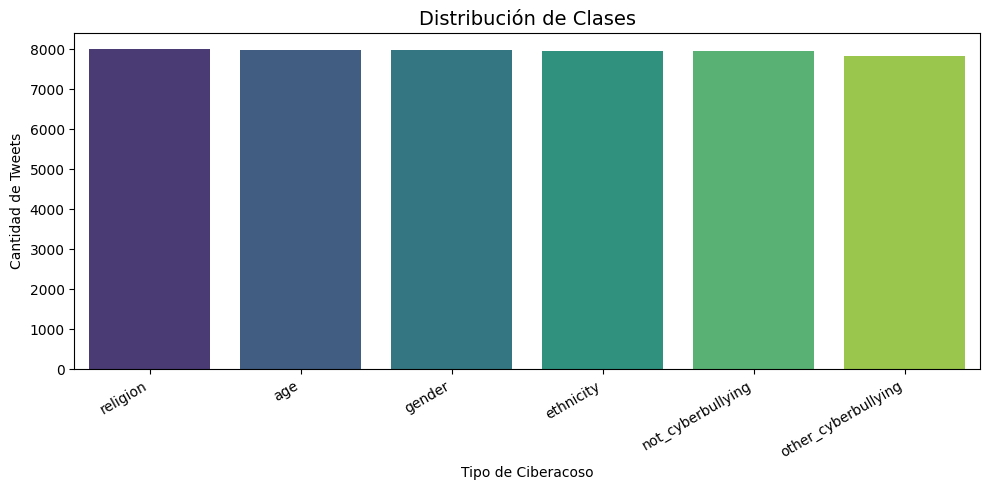

C:\Users\jplop\AppData\Local\Temp\ipykernel_85924\2046869795.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cyberbullying_type', y='tweet_length', order=order, palette='viridis')


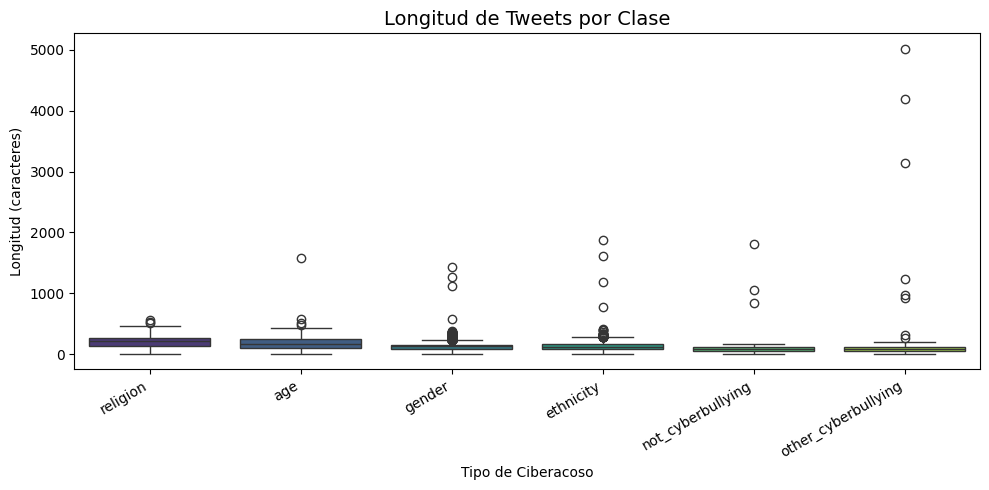

=== ESTADÍSTICAS DE LONGITUD DE TWEETS ===
                      count   mean   std   min    25%    50%    75%     max
cyberbullying_type                                                         
age                  7992.0  173.5  80.1  11.0  105.0  171.0  252.0  1585.0
ethnicity            7961.0  139.3  76.8   5.0   88.0  126.0  167.0  1869.0
gender               7973.0  136.4  71.4   2.0   89.0  129.0  147.0  1431.0
not_cyberbullying    7945.0   83.1  45.5   2.0   49.0   81.0  119.0  1809.0
other_cyberbullying  7823.0   85.7  91.7   1.0   51.0   83.0  121.0  5018.0
religion             7998.0  198.0  71.9   7.0  134.0  212.0  269.0   568.0


In [3]:
# ============================================================
#  Análisis Exploratorio de Datos
# ============================================================

# --- Gráfica 1: Distribución de clases ---
plt.figure(figsize=(10, 5))
order = df['cyberbullying_type'].value_counts().index
sns.countplot(data=df, x='cyberbullying_type', order=order, palette='viridis')
plt.title('Distribución de Clases', fontsize=14)
plt.xlabel('Tipo de Ciberacoso')
plt.ylabel('Cantidad de Tweets')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150)
plt.show()

# --- Gráfica 2: Longitud de tweets por clase ---
df['tweet_length'] = df['tweet_text'].apply(len)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='cyberbullying_type', y='tweet_length', order=order, palette='viridis')
plt.title('Longitud de Tweets por Clase', fontsize=14)
plt.xlabel('Tipo de Ciberacoso')
plt.ylabel('Longitud (caracteres)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('longitud_tweets.png', dpi=150)
plt.show()

# --- Estadísticas de longitud ---
print("=== ESTADÍSTICAS DE LONGITUD DE TWEETS ===")
print(df.groupby('cyberbullying_type')['tweet_length'].describe().round(1))

In [5]:
# ============================================================
#  Limpieza y Preprocesamiento de Texto (NLP Pipeline)
# ============================================================
import re
import nltk

# Descargar recursos necesarios de NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Inicializar el lematizador y stopwords en inglés
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def limpiar_tweet(texto):
    # 1. Convertir a minúsculas
    texto = texto.lower()
    # 2. Eliminar URLs
    texto = re.sub(r'http\S+|www\S+', '', texto)
    # 3. Eliminar menciones (@usuario)
    texto = re.sub(r'@\w+', '', texto)
    # 4. Eliminar hashtags (#tema)
    texto = re.sub(r'#\w+', '', texto)
    # 5. Eliminar caracteres especiales, números y emojis
    texto = re.sub(r'[^a-z\s]', '', texto)
    # 6. Eliminar espacios extra
    texto = re.sub(r'\s+', ' ', texto).strip()
    # 7. Tokenizar (separar en palabras)
    palabras = texto.split()
    # 8. Eliminar stopwords y lematizar
    palabras = [lemmatizer.lemmatize(p) for p in palabras if p not in stop_words]
    return ' '.join(palabras)

# Aplicar limpieza a todos los tweets
print("Limpiando tweets...")
df['tweet_clean'] = df['tweet_text'].apply(limpiar_tweet)

# Verificar resultados
print("\n=== EJEMPLO DE LIMPIEZA ===")
for i in range(3):
    print(f"\nORIGINAL:  {df['tweet_text'].iloc[i]}")
    print(f"LIMPIO:    {df['tweet_clean'].iloc[i]}")

# Verificar tweets vacíos después de limpiar
vacios = (df['tweet_clean'].str.strip() == '').sum()
print(f"\n=== TWEETS VACÍOS DESPUÉS DE LIMPIAR: {vacios} ===")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jplop\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jplop\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\jplop\AppData\Roaming\nltk_data...


Limpiando tweets...

=== EJEMPLO DE LIMPIEZA ===

ORIGINAL:  In other words #katandandre, your food was crapilicious! #mkr
LIMPIO:    word food crapilicious

ORIGINAL:  Why is #aussietv so white? #MKR #theblock #ImACelebrityAU #today #sunrise #studio10 #Neighbours #WonderlandTen #etc
LIMPIO:    white

ORIGINAL:  @XochitlSuckkks a classy whore? Or more red velvet cupcakes?
LIMPIO:    classy whore red velvet cupcake

=== TWEETS VACÍOS DESPUÉS DE LIMPIAR: 477 ===


In [6]:
# ============================================================
#  Eliminación de vacíos y Vectorización TF-IDF
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Eliminar tweets que quedaron vacíos después de limpiar
df = df[df['tweet_clean'].str.strip() != '']
print(f"Tweets restantes después de limpieza: {len(df)}")

# --- Separar X (texto) e y (etiqueta) ---
X = df['tweet_clean']
y = df['cyberbullying_type']

# --- División Train/Test (80% entrenamiento, 20% prueba) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTamaño Train: {len(X_train)} tweets")
print(f"Tamaño Test:  {len(X_test)} tweets")

# --- Vectorización TF-IDF ---
# max_features=10000: usar las 10,000 palabras más importantes
# ngram_range=(1,2): considerar palabras solas y pares de palabras
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# Ajustar SOLO con train, transformar ambos
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"\nDimensión matriz Train: {X_train_tfidf.shape}")
print(f"Dimensión matriz Test:  {X_test_tfidf.shape}")
print("\n Vectorización TF-IDF completada")

Tweets restantes después de limpieza: 47215

Tamaño Train: 37772 tweets
Tamaño Test:  9443 tweets

Dimensión matriz Train: (37772, 10000)
Dimensión matriz Test:  (9443, 10000)

 Vectorización TF-IDF completada


Entrenando Naive Bayes...

=== NAIVE BAYES ===
Accuracy Train: 0.8430
Accuracy Test:  0.7697

Reporte de Clasificación (Test):
                     precision    recall  f1-score   support

                age       0.84      0.96      0.90      1598
          ethnicity       0.90      0.91      0.91      1591
             gender       0.86      0.78      0.82      1585
  not_cyberbullying       0.58      0.42      0.49      1555
other_cyberbullying       0.56      0.56      0.56      1514
           religion       0.80      0.96      0.88      1600

           accuracy                           0.77      9443
          macro avg       0.76      0.77      0.76      9443
       weighted avg       0.76      0.77      0.76      9443



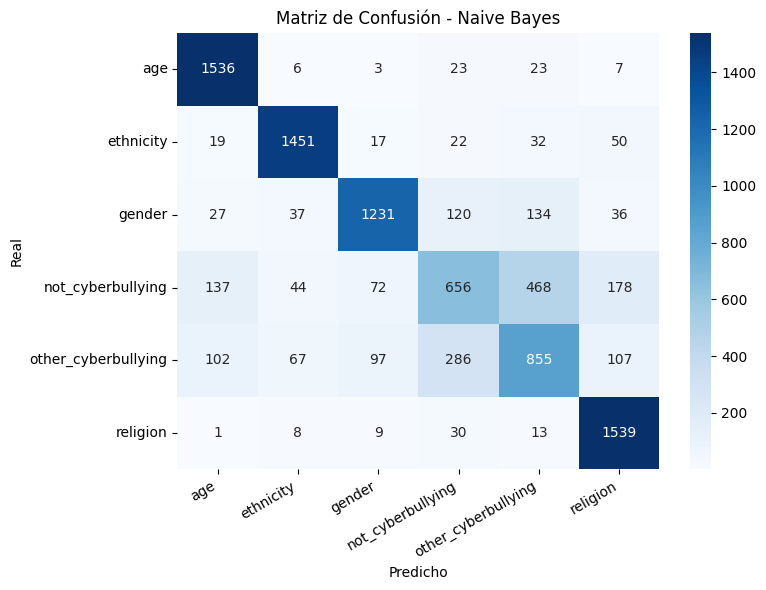

In [7]:
# ============================================================
# Modelo 1: Naive Bayes
# ============================================================
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Entrenando Naive Bayes...")
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)

# Predicciones
y_pred_nb_train = nb_model.predict(X_train_tfidf)
y_pred_nb_test  = nb_model.predict(X_test_tfidf)

# Métricas
acc_nb_train = accuracy_score(y_train, y_pred_nb_train)
acc_nb_test  = accuracy_score(y_test,  y_pred_nb_test)

print(f"\n=== NAIVE BAYES ===")
print(f"Accuracy Train: {acc_nb_train:.4f}")
print(f"Accuracy Test:  {acc_nb_test:.4f}")
print(f"\nReporte de Clasificación (Test):")
print(classification_report(y_test, y_pred_nb_test))

# Matriz de confusión
plt.figure(figsize=(8, 6))
cm_nb = confusion_matrix(y_test, y_pred_nb_test, labels=nb_model.classes_)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=nb_model.classes_,
            yticklabels=nb_model.classes_)
plt.title('Matriz de Confusión - Naive Bayes')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_nb.png', dpi=150)
plt.show()

Entrenando Regresión Logística (puede tardar 1-2 minutos)...


c:\Users\jplop\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



=== REGRESIÓN LOGÍSTICA ===
Accuracy Train: 0.8834
Accuracy Test:  0.8179

Reporte de Clasificación (Test):
                     precision    recall  f1-score   support

                age       0.95      0.97      0.96      1598
          ethnicity       0.98      0.97      0.98      1591
             gender       0.90      0.83      0.86      1585
  not_cyberbullying       0.56      0.55      0.55      1555
other_cyberbullying       0.58      0.63      0.60      1514
           religion       0.95      0.94      0.94      1600

           accuracy                           0.82      9443
          macro avg       0.82      0.82      0.82      9443
       weighted avg       0.82      0.82      0.82      9443



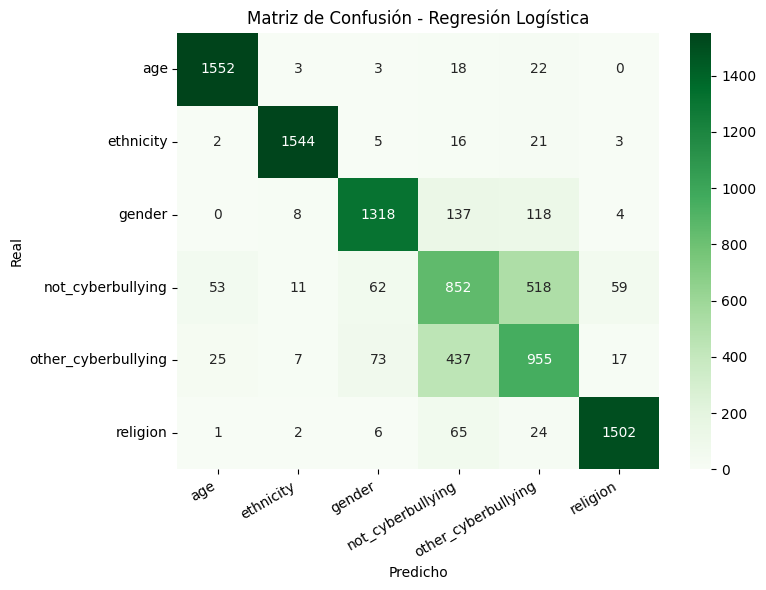

In [8]:
# ============================================================
# Modelo 2: Regresión Logística
# ============================================================
from sklearn.linear_model import LogisticRegression

print("Entrenando Regresión Logística (puede tardar 1-2 minutos)...")
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='saga',
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train_tfidf, y_train)

# Predicciones
y_pred_lr_train = lr_model.predict(X_train_tfidf)
y_pred_lr_test  = lr_model.predict(X_test_tfidf)

# Métricas
acc_lr_train = accuracy_score(y_train, y_pred_lr_train)
acc_lr_test  = accuracy_score(y_test,  y_pred_lr_test)

print(f"\n=== REGRESIÓN LOGÍSTICA ===")
print(f"Accuracy Train: {acc_lr_train:.4f}")
print(f"Accuracy Test:  {acc_lr_test:.4f}")
print(f"\nReporte de Clasificación (Test):")
print(classification_report(y_test, y_pred_lr_test))

# Matriz de confusión
plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, y_pred_lr_test, labels=lr_model.classes_)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=lr_model.classes_,
            yticklabels=lr_model.classes_)
plt.title('Matriz de Confusión - Regresión Logística')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_lr.png', dpi=150)
plt.show()

Entrenando Red Neuronal (puede tardar 3-5 minutos)...
Iteration 1, loss = 0.82777225
Iteration 2, loss = 0.34082543
Iteration 3, loss = 0.25832729
Iteration 4, loss = 0.21695970
Iteration 5, loss = 0.19090760
Iteration 6, loss = 0.17093375
Iteration 7, loss = 0.15538321
Iteration 8, loss = 0.14295231
Iteration 9, loss = 0.13209213
Iteration 10, loss = 0.12217028
Iteration 11, loss = 0.11401934
Iteration 12, loss = 0.10756893
Iteration 13, loss = 0.10197005
Iteration 14, loss = 0.09657300
Iteration 15, loss = 0.09288700
Iteration 16, loss = 0.08886100
Iteration 17, loss = 0.08634921
Iteration 18, loss = 0.08348399
Iteration 19, loss = 0.08132624
Iteration 20, loss = 0.08039675
Iteration 21, loss = 0.07776647
Iteration 22, loss = 0.07611904
Iteration 23, loss = 0.07586990
Iteration 24, loss = 0.07328461
Iteration 25, loss = 0.07285222
Iteration 26, loss = 0.07078460
Iteration 27, loss = 0.06976519
Iteration 28, loss = 0.07001460
Iteration 29, loss = 0.06870186
Iteration 30, loss = 0.0676

c:\Users\jplop\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(



=== RED NEURONAL (MLP) ===
Accuracy Train: 0.9648
Accuracy Test:  0.7688

Reporte de Clasificación (Test):
                     precision    recall  f1-score   support

                age       0.93      0.95      0.94      1598
          ethnicity       0.98      0.94      0.96      1591
             gender       0.84      0.81      0.83      1585
  not_cyberbullying       0.45      0.52      0.48      1555
other_cyberbullying       0.49      0.47      0.48      1514
           religion       0.93      0.90      0.91      1600

           accuracy                           0.77      9443
          macro avg       0.77      0.77      0.77      9443
       weighted avg       0.78      0.77      0.77      9443



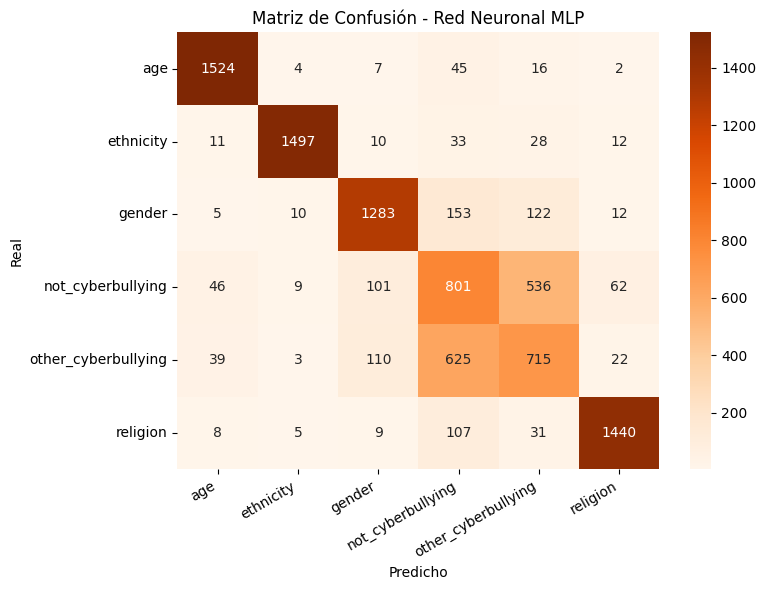

In [9]:
# ============================================================
# Modelo 3: Red Neuronal (MLP)
# ============================================================
from sklearn.neural_network import MLPClassifier

print("Entrenando Red Neuronal (puede tardar 3-5 minutos)...")
mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),  # 2 capas ocultas
    activation='relu',
    max_iter=30,
    batch_size=256,
    learning_rate_init=0.001,
    random_state=42,
    verbose=True
)
mlp_model.fit(X_train_tfidf, y_train)

# Predicciones
y_pred_mlp_train = mlp_model.predict(X_train_tfidf)
y_pred_mlp_test  = mlp_model.predict(X_test_tfidf)

# Métricas
acc_mlp_train = accuracy_score(y_train, y_pred_mlp_train)
acc_mlp_test  = accuracy_score(y_test,  y_pred_mlp_test)

print(f"\n=== RED NEURONAL (MLP) ===")
print(f"Accuracy Train: {acc_mlp_train:.4f}")
print(f"Accuracy Test:  {acc_mlp_test:.4f}")
print(f"\nReporte de Clasificación (Test):")
print(classification_report(y_test, y_pred_mlp_test))

# Matriz de confusión
plt.figure(figsize=(8, 6))
cm_mlp = confusion_matrix(y_test, y_pred_mlp_test, labels=mlp_model.classes_)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Oranges',
            xticklabels=mlp_model.classes_,
            yticklabels=mlp_model.classes_)
plt.title('Matriz de Confusión - Red Neuronal MLP')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_mlp.png', dpi=150)
plt.show()